
# Tutorial 7 — **Scikit‑learn**: Primeros pasos, *Pipelines*, **Regresión** y **Clasificación**


**Objetivo**: Conocer el flujo de trabajo de **Scikit‑learn** (fit → predict → score), armar **pipelines** de preprocesamiento + modelo, y entrenar **un ejemplo de regresión** y **otro de clasificación** con métrica y visualización básica.




<a id="material"></a>
## 1) Material de estudio



<a id="intro"></a>
### 1.1 ¿Qué es Scikit‑learn y cómo se usa?

**Scikit‑learn** es una biblioteca de *machine learning* en Python con una API **consistente** basada en tres métodos clave:
- `fit(X, y)`: **entrena** el modelo con datos de entrada `X` y objetivo `y`.
- `predict(X_new)`: **predice** con el modelo ya entrenado.
- `score(X, y)`: **evalúa** el desempeño usando una métrica por defecto (depende del estimador).

En un flujo típico:
-- 1) preparas los datos, 2) eliges un modelo, 3) entrenas, 4) evalúas con métricas adecuadas (según sea regresión o clasificación).


<a id="xy"></a>
### 1.2 `X` y `y`: selección y preparación de datos

- `X` (**matriz de características**) debe ser 2D: `(n_muestras, n_características)`.
- `y` (**vector objetivo**) es 1D con la variable a predecir.
- Es buena práctica separar **conjunto de entrenamiento** y **de prueba** para medir generalización.



<a id="fit-predict-score"></a>
### 1.3 Entrenamiento, predicción y evaluación

Herramientas comunes:
- `train_test_split` para dividir datos.
- Métricas de **regresión**: `r2_score`, `mean_absolute_error (MAE)`, `mean_squared_error (MSE)` / `RMSE`.
- Métricas de **clasificación**: `accuracy_score`, `precision_recall_fscore_support`, `confusion_matrix`.


In [1]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Funciones clave importadas correctamente.")

Funciones clave importadas correctamente.



<a id="pipeline"></a>
### 1.4 `Pipeline`: preprocesamiento + modelo

`Pipeline` une pasos en una sola **línea de producción**: por ejemplo, **escalado** (`StandardScaler`) → **modelo**.
Ventajas:
- Evitas fugas de datos (el **scaler** se ajusta **solo** con entrenamiento).
- Facilita **validación cruzada** y **búsqueda de hiperparámetros** (`GridSearchCV`) sin repetir código.


In [2]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Pipeline y StandardScaler listos para usar.")

Pipeline y StandardScaler listos para usar.



<a id="cv-grid"></a>
### 1.5 Validación cruzada y *grid search*  (idea)

- **Validación cruzada** (`cross_val_score`) evalúa el modelo en varios *folds* para obtener un desempeño más estable.  
- **Grid search** (`GridSearchCV`) prueba combinaciones de hiperparámetros para encontrar la mejor configuración dentro de una grilla definida.



<a id="ejemplos"></a>
## 2) Ejemplos



<a id="regresion"></a>
### 2.1 **Regresión** lineal con dataset `diabetes`

Objetivo: predecir la **progresión** (variable `target`) a partir de características clínicas.  
Haremos dos variantes:
1) **Una sola característica** (IMC/BMI) para visualizar el ajuste.
2) **Todas las características** para comparar desempeño.


In [3]:

# --- REGRESIÓN (diabetes) -----------------------------------------------
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Cargar datos
data = load_diabetes()
X_all = data.data            # (n, p) características estandarizadas
y = data.target              # (n,) progresión

print("Dataset diabetes cargado.")
print(" - Muestras:", X_all.shape[0], "| Características:", X_all.shape[1])

Dataset diabetes cargado.
 - Muestras: 442 | Características: 10


In [4]:
# Usar solo BMI (índice 2 en este dataset)
idx_bmi = np.where(np.array(data.feature_names) == "bmi")[0][0]
## Tambien pueden usar idx_bmi = list(data.feature_names).index("bmi")
X_bmi = X_all[:, [idx_bmi]]  # 2D

# Split
Xtr_bmi, Xte_bmi, ytr, yte = train_test_split(X_bmi, y, test_size=0.2, random_state=42)
print("\nUsando SOLO BMI como característica...")
print(" - Entrenamiento:", Xtr_bmi.shape, "| Prueba:", Xte_bmi.shape)

# Pipeline: escalado (innecesario aquí porque ya viene escalado, pero lo dejamos por patrón) + LR
pipe_lr_bmi = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # no afectará mucho por datos ya escalados
    ("model", LinearRegression())
])
pipe_lr_bmi.fit(Xtr_bmi, ytr)

# Evaluación
pred_tr = pipe_lr_bmi.predict(Xtr_bmi)
pred_te = pipe_lr_bmi.predict(Xte_bmi)

r2_tr = r2_score(ytr, pred_tr)
r2_te = r2_score(yte, pred_te)
mae_te = mean_absolute_error(yte, pred_te)
mse_te = mean_squared_error(yte, pred_te)
rmse_te = np.sqrt(mse_te)

print("Desempeño con BMI únicamente:")
print(" - R^2 (train):", round(r2_tr, 3))
print(" - R^2 (test):", round(r2_te, 3))
print(" - MAE (test):", round(mae_te, 2))
print(" - RMSE (test):", round(rmse_te, 2))


Usando SOLO BMI como característica...
 - Entrenamiento: (353, 1) | Prueba: (89, 1)
Desempeño con BMI únicamente:
 - R^2 (train): 0.366
 - R^2 (test): 0.233
 - MAE (test): 52.26
 - RMSE (test): 63.73


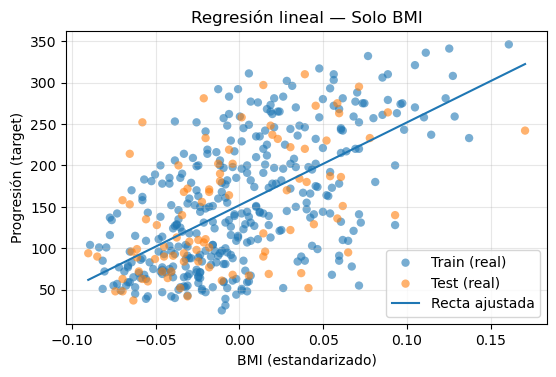

In [5]:

# Visualización 2D: puntos + línea ajustada
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.scatter(Xtr_bmi[:, 0], ytr, alpha=0.6, label="Train (real)", edgecolor="none")
ax.scatter(Xte_bmi[:, 0], yte, alpha=0.6, label="Test (real)", edgecolor="none")

# Línea sobre un rango ordenado
x_line = np.linspace(X_bmi.min(), X_bmi.max(), 200).reshape(-1, 1)
y_line = pipe_lr_bmi.predict(x_line)
ax.plot(x_line[:, 0], y_line, label="Recta ajustada")

ax.set_title("Regresión lineal — Solo BMI")
ax.set_xlabel("BMI (estandarizado)")
ax.set_ylabel("Progresión (target)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [6]:
# Con TODAS las características
Xtr_all, Xte_all, ytr2, yte2 = train_test_split(X_all, y, test_size=0.2, random_state=42)
pipe_lr_all = Pipeline([("model", LinearRegression())])
pipe_lr_all.fit(Xtr_all, ytr2)

pred_te_all = pipe_lr_all.predict(Xte_all)
r2_te_all = r2_score(yte2, pred_te_all)
mae_te_all = mean_absolute_error(yte2, pred_te_all)
mse_te_all = mean_squared_error(yte2, pred_te_all)
rmse_te_all = np.sqrt(mse_te_all)

print("\nUsando TODAS las características:")
print(" - R^2 (test):", round(r2_te_all, 3))
print(" - MAE (test):", round(mae_te_all, 2))
print(" - RMSE (test):", round(rmse_te_all, 2))


Usando TODAS las características:
 - R^2 (test): 0.453
 - MAE (test): 42.79
 - RMSE (test): 53.85



<a id="clasificacion"></a>
### 2.2 **Clasificación** con KNN (`breast_cancer`) y frontera de decisión

Problema: clasificar tumores **benignos vs malignos**.  
Usaremos dos características para **visualizar** la frontera y un `Pipeline` con `StandardScaler` + `KNeighborsClassifier`.


In [7]:
# --- CLASIFICACIÓN (cáncer de mama) -------------------------------------
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier

# Cargar datos
bc = load_breast_cancer(as_frame=True)
df = bc.frame.copy()

# Seleccionamos 2 variables para visualizar (ajusta si tus columnas difieren)
feat_x = "mean radius"
feat_y = "mean texture"
X2 = df[[feat_x, feat_y]].values
y2 = df["target"].values  # 0/1

print("Dataset breast_cancer cargado.")
print(" - Muestras:", X2.shape[0], "| Características seleccionadas:", X2.shape[1])
print(" - Clases:", dict(zip(bc.target_names, range(len(bc.target_names)))))


Dataset breast_cancer cargado.
 - Muestras: 569 | Características seleccionadas: 2
 - Clases: {'malignant': 0, 'benign': 1}


In [8]:
## Realizamos la separación y el flujo de antes

# Split
Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Pipeline: escalado + KNN
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
pipe_knn.fit(Xtr, ytr)

# Evaluación
ypred = pipe_knn.predict(Xte)
acc = accuracy_score(yte, ypred)
cm = confusion_matrix(yte, ypred)

print("Desempeño KNN (k=5):")
print(" - Accuracy (test):", round(acc, 4))
print("\nMatriz de confusión (test):\n", cm)
print("\nReporte de clasificación (test):\n", classification_report(yte, ypred, target_names=bc.target_names))

Desempeño KNN (k=5):
 - Accuracy (test): 0.8772

Matriz de confusión (test):
 [[35  7]
 [ 7 65]]

Reporte de clasificación (test):
               precision    recall  f1-score   support

   malignant       0.83      0.83      0.83        42
      benign       0.90      0.90      0.90        72

    accuracy                           0.88       114
   macro avg       0.87      0.87      0.87       114
weighted avg       0.88      0.88      0.88       114



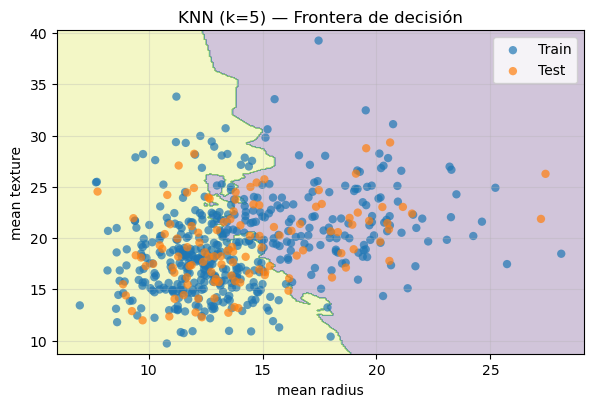

In [9]:
# Frontera de decisión (malla 2D)
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = X2[:,0].min() - 1, X2[:,0].max() + 1
y_min, y_max = X2[:,1].min() - 1, X2[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = pipe_knn.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.contourf(xx, yy, Z, alpha=0.25)  # regiones de decisión
# Muestras de entrenamiento y test
ax.scatter(Xtr[:,0], Xtr[:,1], alpha=0.7, edgecolor="none", label="Train")
ax.scatter(Xte[:,0], Xte[:,1], alpha=0.7, edgecolor="none", label="Test")

ax.set_title("KNN (k=5) — Frontera de decisión")
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


<a id="ejercicios"></a>
## 3) Ejercicios

> **Sugerencia**: agrega `print(...)` descriptivos en cada paso (tamaños, hiperparámetros, métricas).

### Ejercicio 1 — *Pipeline* de regresión (diabetes)
1. Repite la regresión con `LinearRegression`, pero usa **solo** dos características: `bmi` y `bp` (presión sanguínea).  
2. Reporta `R^2`, `MAE`, `RMSE` en *test*.  
3. (Opcional) Agrega `PolynomialFeatures` (grado 2) y compara.



In [28]:

# Tu solución aquí



### Ejercicio 2 — *Pipeline* de clasificación (KNN)
1. Usa el dataset `breast_cancer` y un `Pipeline(StandardScaler → KNN)`.  
2. Prueba con distintos `k = 3, 5, 11` pueden usar (`cross_val_score`, `cv=5`), o por separado para ver.  
3. Elige el mejor `k`, re‑entrena con todo **train** y reporta `accuracy` en **test**.


In [ ]:
# Tu solución aquí



### Ejercicio 3 — *GridSearchCV* (opcional)
Realiza una búsqueda de hiperparámetros para `KNeighborsClassifier`:  
- `n_neighbors = [3, 5, 7, 9, 11]`, `weights = ['uniform', 'distance']`.  
Reporta el **mejor** conjunto y su *score*.


In [ ]:
# Tu solución aquí